## swiGLU 5 — What actually improved global recovery?

In [61]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import seaborn as sns
from IPython.display import display


#### Setup and completed artifacts

In [62]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')


PROJECT_ROOT = find_project_root(Path.cwd())
RESULT_ROOT = (
    PROJECT_ROOT / 'data' / 'results' / 'workflows' / 'model'
)
SEARCH_ARTIFACT = RESULT_ROOT / 'swiglu-5' / 'search' / 'run-001.json'
CONFIRMATION_ARTIFACTS = {
    '0.2': RESULT_ROOT / 'swiglu-5' / 'confirmation' / 'run-001-target-0.2.json',
    '0.5': RESULT_ROOT / 'swiglu-5' / 'confirmation' / 'run-001-target-0.5.json',
}
SWIGLU_4_ARTIFACT = RESULT_ROOT / 'swiglu-4' / 'run-001.json'


In [63]:
required_artifacts = [
    SEARCH_ARTIFACT, SWIGLU_4_ARTIFACT, *CONFIRMATION_ARTIFACTS.values()
]
missing_artifacts = [path for path in required_artifacts if not path.is_file()]
if missing_artifacts:
    missing_list = '\n'.join(str(path) for path in missing_artifacts)
    raise FileNotFoundError(f'Missing report artifact(s):\n{missing_list}')

search = json.loads(SEARCH_ARTIFACT.read_text(encoding='utf-8'))
swiglu_4 = json.loads(SWIGLU_4_ARTIFACT.read_text(encoding='utf-8'))
confirmations = {
    target: json.loads(path.read_text(encoding='utf-8'))
    for target, path in CONFIRMATION_ARTIFACTS.items()
}
if search.get('workflow') != 'swiglu-5-search' or search.get('status') != 'completed':
    raise ValueError('Expected a completed SwiGLU-5 search artifact')
for target, artifact in confirmations.items():
    if artifact.get('workflow') != 'swiglu-5-confirmation':
        raise ValueError(f'Expected a confirmation artifact for {target}')
    if artifact.get('status') != 'completed':
        raise ValueError(f'Confirmation {target} is not completed')


In [64]:
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)


In [65]:
FALLBACK_CANDIDATE_DEFINITIONS = {
    'S5-C0': {
        'name': 'Legacy allocation control',
        'short_label': 'Legacy control',
        'initialization': 'Exact SwiGLU-3 fitted operators',
        'allocation': 'SwiGLU-3 ranked widths',
        'question': 'How much does the stronger recovery recipe improve the original construction?',
    },
    'S5-C1': {
        'name': 'Output-reconstructed initialization',
        'short_label': 'Output reconstruction',
        'initialization': 'Output-aware reconstruction',
        'allocation': 'SwiGLU-3 ranked widths',
        'question': 'Does a better local initialization help without changing widths?',
    },
    'S5-C2': {
        'name': 'Discrete layer allocation',
        'short_label': 'Discrete allocation',
        'initialization': 'Legacy teacher-neuron subset',
        'allocation': 'Discrete per-layer width optimization',
        'question': 'Does concentrating compression in tolerant layers improve recovery?',
    },
    'S5-C3': {
        'name': 'Reconstruction plus discrete allocation',
        'short_label': 'Combined strategy',
        'initialization': 'Output-aware reconstruction',
        'allocation': 'Discrete per-layer width optimization',
        'question': 'Are reconstruction and discrete allocation complementary?',
    },
    'S5-C4': {
        'name': 'Composition-aware refinement',
        'short_label': 'Composition-aware',
        'initialization': 'Refit on compressed-model activation context',
        'allocation': 'Widths of the best pre-recovery parent',
        'question': 'Does fitting in the assembled student context reduce composition error?',
    },
}
candidate_definitions = search.get('definitions', {}).get(
    'candidates', FALLBACK_CANDIDATE_DEFINITIONS
)


In [66]:
CANDIDATE_ORDER = ['S5-C0', 'S5-C1', 'S5-C2', 'S5-C3', 'S5-C4']
STRATEGY_ORDER = [
    candidate_definitions[candidate_id]['short_label']
    for candidate_id in CANDIDATE_ORDER
]
strategy_colors = sns.color_palette('colorblind', len(CANDIDATE_ORDER))
STRATEGY_PALETTE = dict(zip(STRATEGY_ORDER, strategy_colors))


In [67]:
def strategy_label(candidate_id):
    return candidate_definitions[candidate_id]['short_label']


def full_evaluation(candidate, requested_tokens):
    matches = [
        row
        for row in candidate['recovery']['full_evaluations']
        if requested_tokens in [int(value) for value in row['requested_tokens']]
        and int(row['actual_tokens']) >= requested_tokens
    ]
    if not matches:
        return None
    return min(matches, key=lambda row: (row['actual_tokens'], row['optimizer_updates']))


#### Experimental design

In [68]:
strategy_rows = []
for candidate_id in CANDIDATE_ORDER:
    definition = candidate_definitions[candidate_id]
    strategy_rows.append({
        'Strategy': definition['name'],
        'Initialization': definition['initialization'],
        'Width allocation': definition['allocation'],
        'Scientific question': definition['question'],
        'Artifact key': candidate_id,
    })
strategy_df = pd.DataFrame(strategy_rows)
display(strategy_df)


,Strategy,Initialization,Width allocation,Scientific question,Artifact key
0,Legacy allocation control,Exact SwiGLU-3 fitted operators,SwiGLU-3 ranked widths,How much does the stronger recovery recipe improve the original construction?,S5-C0
1,Output-reconstructed initialization,Output-aware reconstruction,SwiGLU-3 ranked widths,Does a better local initialization help without changing widths?,S5-C1
2,Discrete layer allocation,Legacy teacher-neuron subset,Discrete per-layer width optimization,Does concentrating compression in tolerant layers improve recovery?,S5-C2
3,Reconstruction plus discrete allocation,Output-aware reconstruction,Discrete per-layer width optimization,Are reconstruction and discrete allocation complementary?,S5-C3
4,Composition-aware refinement,Refit on compressed-model activation context,Widths of the best pre-recovery parent,Does fitting in the assembled student context reduce composition error?,S5-C4


In [69]:
protocol = search.get('definitions', {}).get('recovery_protocol', {
    'name': 'Replacement-only teacher distillation',
    'objective': 'Teacher-to-student KL at temperature 1',
    'learning_rate': 'Constant 3e-5',
    'trainable_scope': 'Compressed SwiGLU replacements only',
    'effective_tokens_per_update': 2048,
})
protocol_df = pd.DataFrame([
    {'Setting': key.replace('_', ' ').title(), 'Value': value}
    for key, value in protocol.items()
])
display(protocol_df)


,Setting,Value
0,Name,Replacement-only teacher distillation
1,Objective,Teacher-to-student KL at temperature 1
2,Learning Rate,Constant 3e-5
3,Trainable Scope,Compressed SwiGLU replacements only
4,Effective Tokens Per Update,2048


#### Search — which idea mattered?

In [70]:
search_rows = []
for target, candidates in search['results']['candidates'].items():
    for candidate_id in CANDIDATE_ORDER:
        candidate = candidates[candidate_id]
        row_2m = full_evaluation(candidate, 2_000_000)
        row_5m = full_evaluation(candidate, 5_000_000)
        search_rows.append({
            'target': target,
            'target_label': f'{float(target):.0%} removal',
            'strategy': strategy_label(candidate_id),
            'artifact_key': candidate_id,
            'pre_kl': candidate['pre_recovery']['recovery_validation_kl'],
            'pre_ppl': candidate['pre_recovery']['wikitext_validation']['perplexity'],
            'kl_2m': row_2m['recovery_validation_kl'],
            'ppl_2m': row_2m['wikitext_validation']['perplexity'],
            'kl_5m': None if row_5m is None else row_5m['recovery_validation_kl'],
            'ppl_5m': None if row_5m is None else row_5m['wikitext_validation']['perplexity'],
            'trained_tokens': candidate['recovery']['tokens_seen'],
        })
search_df = pd.DataFrame(search_rows)
display(search_df)


,target,target_label,strategy,artifact_key,pre_kl,pre_ppl,kl_2m,ppl_2m,kl_5m,ppl_5m,trained_tokens
0,0.2,20% removal,Legacy control,S5-C0,0.123033,17.687568,0.102378,17.312830,0.096449,17.205452,5001216
1,0.2,20% removal,Output reconstruction,S5-C1,0.125172,17.557658,0.104084,17.274573,NaN,NaN,2000896
2,0.2,20% removal,Discrete allocation,S5-C2,0.110401,16.905971,0.093414,16.459381,0.091872,16.404357,5001216
3,0.2,20% removal,Combined strategy,S5-C3,0.110118,16.897258,0.093477,16.419650,0.091744,16.375111,5001216
4,0.2,20% removal,Composition-aware,S5-C4,0.114065,16.893890,0.094529,16.400969,NaN,NaN,2000896
5,0.5,50% removal,Legacy control,S5-C0,0.407479,28.914613,0.308412,25.271848,0.284632,24.459374,5001216
6,0.5,50% removal,Output reconstruction,S5-C1,0.403978,28.659525,0.310213,25.140612,NaN,NaN,2000896
7,0.5,50% removal,Discrete allocation,S5-C2,0.397470,28.181039,0.300836,24.128175,0.281350,23.305167,5001216
8,0.5,50% removal,Combined strategy,S5-C3,0.396766,28.173408,0.301429,24.111192,0.282249,23.319976,5001216
9,0.5,50% removal,Composition-aware,S5-C4,0.459195,30.683586,0.305023,24.043184,NaN,NaN,2000896


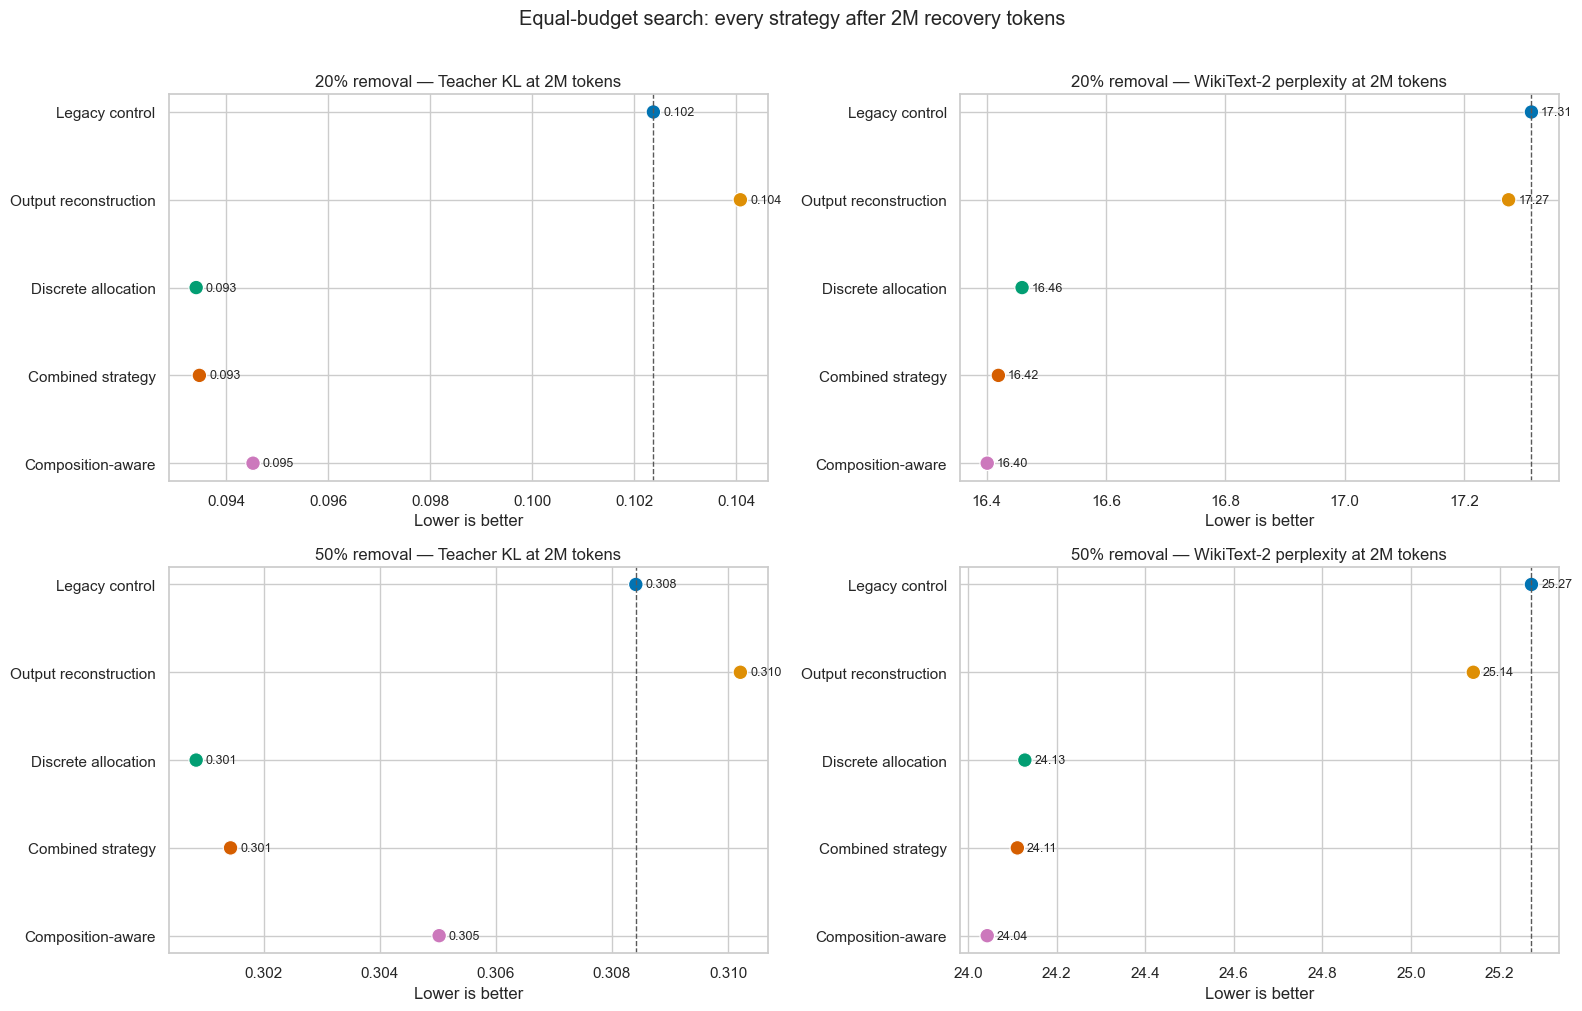

In [71]:
figure, axes = plt.subplots(2, 2, figsize=(16, 10))
metric_columns = [
    ('kl_2m', 'Teacher KL at 2M tokens', '{:.3f}'),
    ('ppl_2m', 'WikiText-2 perplexity at 2M tokens', '{:.2f}'),
]
for row_index, target in enumerate(('0.2', '0.5')):
    target_frame = search_df[search_df['target'] == target].copy()
    target_frame['strategy'] = pd.Categorical(
        target_frame['strategy'], categories=STRATEGY_ORDER, ordered=True
    )
    target_frame = target_frame.sort_values('strategy')
    for column_index, (metric, title, value_format) in enumerate(metric_columns):
        axis = axes[row_index, column_index]
        sns.scatterplot(
            data=target_frame,
            x=metric,
            y='strategy',
            hue='strategy',
            palette=STRATEGY_PALETTE,
            s=110,
            legend=False,
            ax=axis,
        )
        control_value = target_frame.loc[
            target_frame['artifact_key'] == 'S5-C0', metric
        ].iloc[0]
        axis.axvline(
            control_value, color='0.35', linestyle='--', linewidth=1,
            label='Legacy control'
        )
        for strategy, value in zip(target_frame['strategy'], target_frame[metric]):
            axis.annotate(
                value_format.format(value),
                (value, strategy),
                xytext=(7, 0),
                textcoords='offset points',
                va='center',
                fontsize=9,
            )
        axis.set(
            title=f'{float(target):.0%} removal — {title}',
            xlabel='Lower is better',
            ylabel='',
        )
figure.suptitle('Equal-budget search: every strategy after 2M recovery tokens', y=1.01)
figure.tight_layout()
plt.show()


In [72]:
search_curve_rows = []
for target, evidence in search['results']['published_swiglu_3'].items():
    for row in evidence['validation_history']:
        if row['tokens_seen'] <= 5_100_000:
            search_curve_rows.append({
                'target': target,
                'strategy': 'SwiGLU-3 published',
                'tokens_millions': row['tokens_seen'] / 1e6,
                'validation_kl': row['recovery_validation_kl'],
            })
for target, candidates in search['results']['candidates'].items():
    for candidate_id, candidate in candidates.items():
        for row in candidate['recovery']['validation_history']:
            search_curve_rows.append({
                'target': target,
                'strategy': strategy_label(candidate_id),
                'tokens_millions': row['actual_tokens'] / 1e6,
                'validation_kl': row['recovery_validation_kl'],
            })
search_curve_df = pd.DataFrame(search_curve_rows)
trajectory_order = ['SwiGLU-3 published', *STRATEGY_ORDER]
trajectory_colors = ['0.25', *strategy_colors]
trajectory_palette = dict(zip(trajectory_order, trajectory_colors))


c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

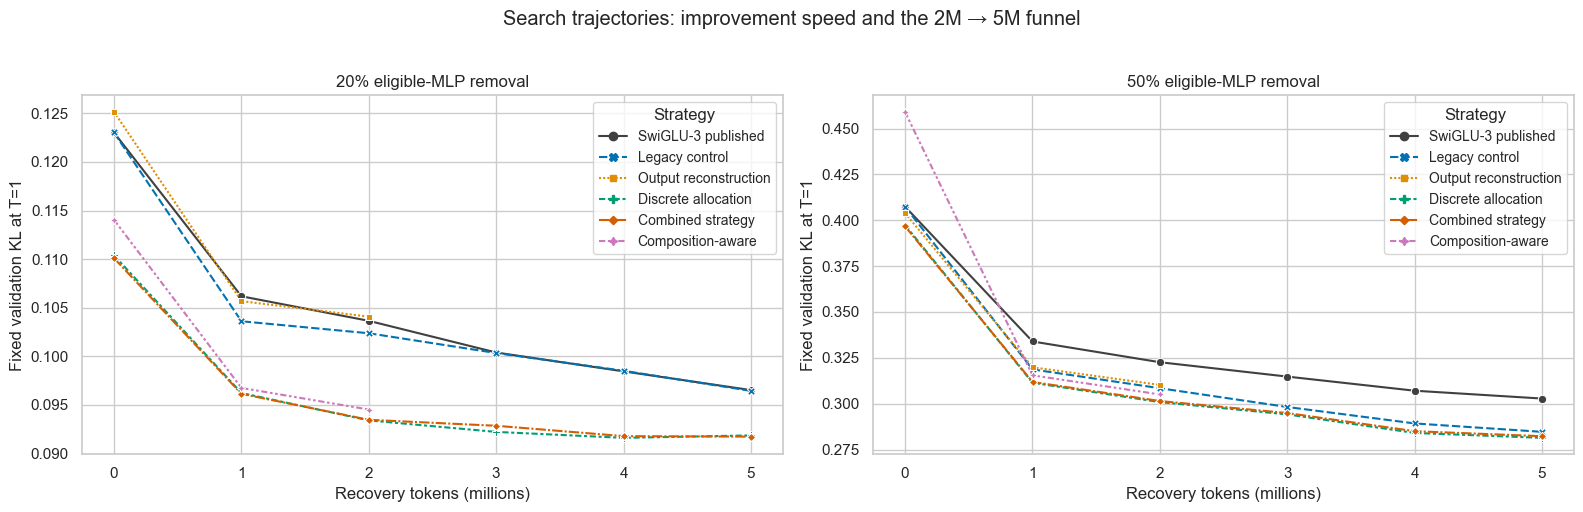

In [73]:
figure, axes = plt.subplots(1, 2, figsize=(16, 5))
for axis, target in zip(axes, ('0.2', '0.5')):
    sns.lineplot(
        data=search_curve_df[search_curve_df['target'] == target],
        x='tokens_millions',
        y='validation_kl',
        hue='strategy',
        style='strategy',
        hue_order=trajectory_order,
        style_order=trajectory_order,
        palette=trajectory_palette,
        markers=True,
        dashes=True,
        estimator=None,
        ax=axis,
    )
    axis.set(
        title=f'{float(target):.0%} eligible-MLP removal',
        xlabel='Recovery tokens (millions)',
        ylabel='Fixed validation KL at T=1',
    )
    axis.legend(title='Strategy', fontsize='small')
figure.suptitle('Search trajectories: improvement speed and the 2M → 5M funnel', y=1.02)
figure.tight_layout()
plt.show()


#### Allocation — where did the parameter budget move?

In [74]:
allocation_rows = []
for target, candidates in search['results']['candidates'].items():
    for candidate_id in CANDIDATE_ORDER:
        for allocation in candidates[candidate_id]['allocation']:
            allocation_rows.append({
                'target': target,
                'candidate': candidate_id,
                'strategy': strategy_label(candidate_id),
                'layer': int(allocation['layer']),
                'width_ratio': (
                    allocation['replacement_width'] / allocation['original_width']
                ),
                'dense_retained': bool(allocation['retains_dense_module']),
                'replacement_parameters': int(allocation['replacement_parameters']),
            })
allocation_df = pd.DataFrame(allocation_rows)


In [75]:
allocation_comparison = allocation_df[
    allocation_df['candidate'].isin(['S5-C0', 'S5-C2'])
].copy()
allocation_comparison['row_label'] = allocation_comparison.apply(
    lambda row: (
        f"{float(row['target']):.0%} · "
        + ('Legacy allocation' if row['candidate'] == 'S5-C0' else 'Discrete allocation')
    ),
    axis=1,
)
row_order = [
    '20% · Legacy allocation',
    '20% · Discrete allocation',
    '50% · Legacy allocation',
    '50% · Discrete allocation',
]
width_matrix = (
    allocation_comparison
    .pivot(index='row_label', columns='layer', values='width_ratio')
    .reindex(row_order)
)


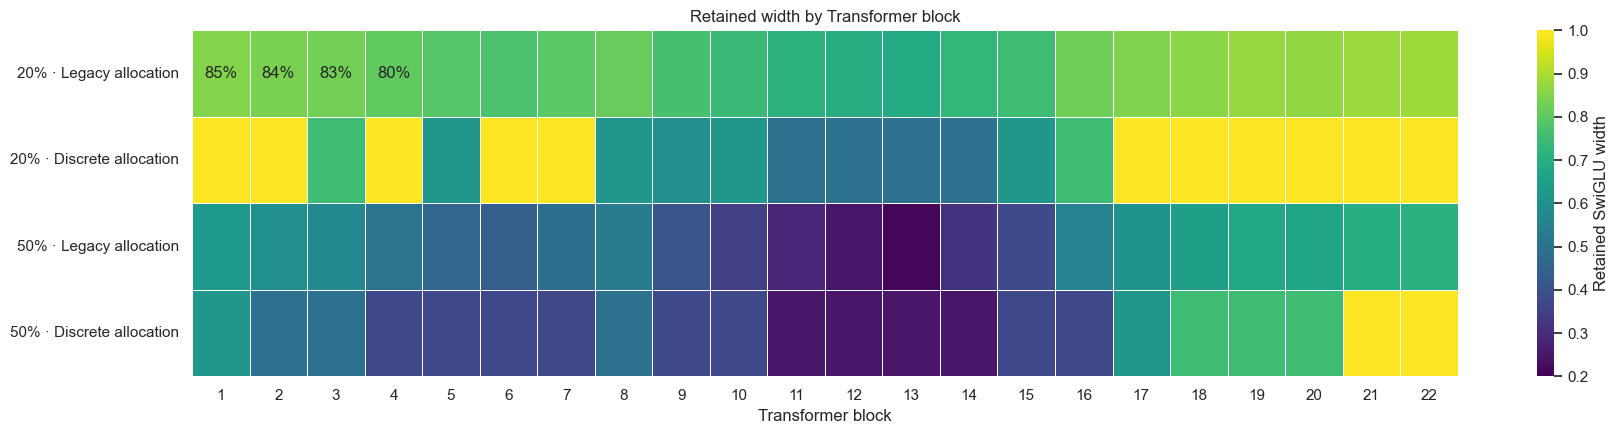

In [76]:
figure, axis = plt.subplots(figsize=(18, 4.5))
sns.heatmap(
    width_matrix,
    annot=True,
    fmt='.0%',
    cmap='viridis',
    vmin=0.2,
    vmax=1.0,
    linewidths=0.4,
    cbar_kws={'label': 'Retained SwiGLU width'},
    ax=axis,
)
axis.set(
    title='Retained width by Transformer block',
    xlabel='Transformer block',
    ylabel='',
)
figure.tight_layout()
plt.show()


c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

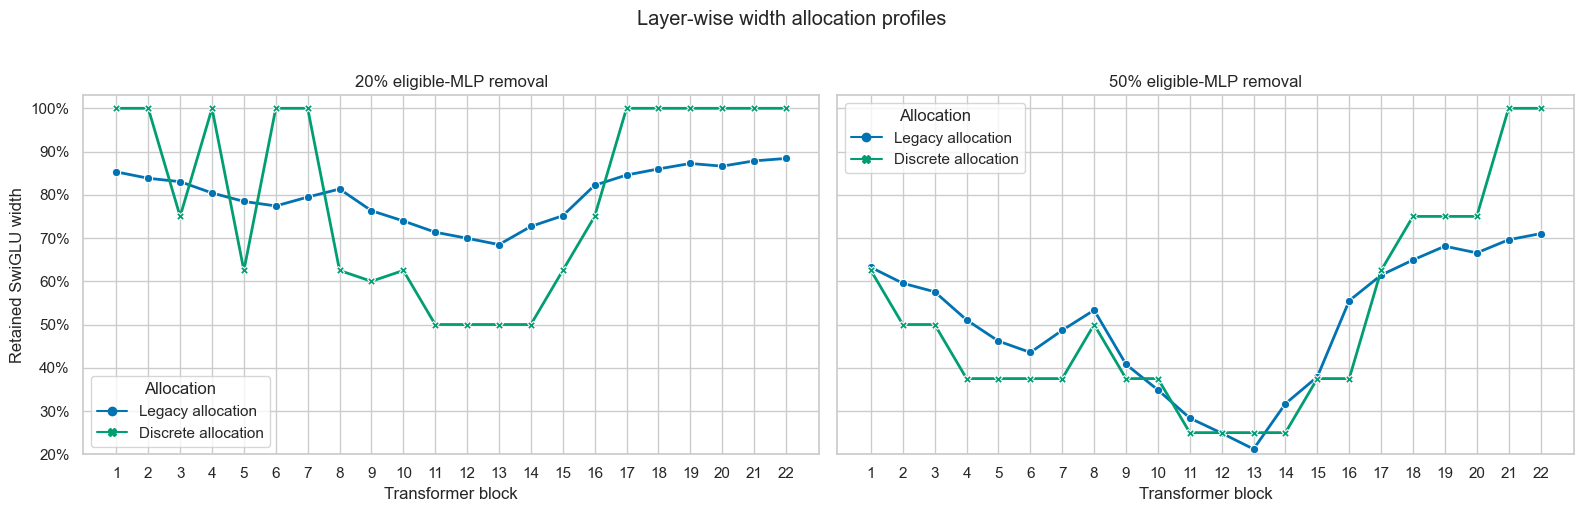

In [77]:
allocation_line_data = allocation_comparison.copy()
allocation_line_data['allocation_method'] = allocation_line_data['candidate'].map({
    'S5-C0': 'Legacy allocation',
    'S5-C2': 'Discrete allocation',
})
allocation_method_order = ['Legacy allocation', 'Discrete allocation']
allocation_palette = {
    'Legacy allocation': STRATEGY_PALETTE['Legacy control'],
    'Discrete allocation': STRATEGY_PALETTE['Discrete allocation'],
}

figure, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for axis, target in zip(axes, ('0.2', '0.5')):
    target_data = allocation_line_data[allocation_line_data['target'] == target]
    sns.lineplot(
        data=target_data,
        x='layer',
        y='width_ratio',
        hue='allocation_method',
        style='allocation_method',
        hue_order=allocation_method_order,
        style_order=allocation_method_order,
        palette=allocation_palette,
        markers=True,
        dashes=False,
        estimator=None,
        linewidth=2,
        ax=axis,
    )
    axis.set(
        title=f'{float(target):.0%} eligible-MLP removal',
        xlabel='Transformer block',
        ylabel='Retained SwiGLU width',
        ylim=(0.2, 1.03),
    )
    axis.set_xticks(sorted(target_data['layer'].unique()))
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    axis.legend(title='Allocation')
figure.suptitle('Layer-wise width allocation profiles', y=1.02)
figure.tight_layout()
plt.show()


In [78]:
allocation_summary_rows = []
for target in ('0.2', '0.5'):
    for candidate_id in ('S5-C0', 'S5-C2'):
        candidate = search['results']['candidates'][target][candidate_id]
        allocation_summary_rows.append({
            'Target': f'{float(target):.0%} removal',
            'Allocation': (
                'Legacy ranked widths' if candidate_id == 'S5-C0'
                else 'Discrete optimized widths'
            ),
            'Dense eligible layers retained': sum(
                bool(row['retains_dense_module']) for row in candidate['allocation']
            ),
            'Trainable replacement parameters (M)': sum(
                int(row['replacement_parameters'])
                for row in candidate['allocation']
                if not row['retains_dense_module']
            ) / 1e6,
        })
display(pd.DataFrame(allocation_summary_rows))


,Target,Allocation,Dense eligible layers retained,Trainable replacement parameters (M)
0,20% removal,Legacy ranked widths,0,885.835776
1,20% removal,Discrete optimized widths,11,332.187648
2,50% removal,Legacy ranked widths,0,553.648128
3,50% removal,Discrete optimized widths,2,452.984832


#### Confirmation — did the advantage survive 100M tokens?

In [79]:
validation_rows = []
dense = search['results']['dense_baseline']
dense_ppl = dense['wikitext_validation']['perplexity']
for target, artifact in confirmations.items():
    published = search['results']['published_swiglu_3'][target]
    selected_id = artifact['results']['selected_candidate_id']
    selected_candidate = search['results']['candidates'][target][selected_id]
    true_search_5m = full_evaluation(selected_candidate, 5_000_000)
    for row in published['validation_history']:
        validation_rows.append({
            'target': target,
            'method': 'SwiGLU-3 baseline',
            'tokens_millions': row['tokens_seen'] / 1e6,
            'validation_kl': row['recovery_validation_kl'],
        })
    validation_rows.append({
        'target': target,
        'method': 'SwiGLU-5 discrete allocation',
        'tokens_millions': true_search_5m['actual_tokens'] / 1e6,
        'validation_kl': true_search_5m['recovery_validation_kl'],
    })
    trajectory = artifact['results']['trajectory']
    for row in trajectory['validation_history']:
        if row['actual_tokens'] > 5_100_000:
            validation_rows.append({
                'target': target,
                'method': 'SwiGLU-5 discrete allocation',
                'tokens_millions': row['actual_tokens'] / 1e6,
                'validation_kl': row['recovery_validation_kl'],
            })
validation_df = pd.DataFrame(validation_rows)


In [80]:
perplexity_rows = []
for target, artifact in confirmations.items():
    published = search['results']['published_swiglu_3'][target]
    selected_id = artifact['results']['selected_candidate_id']
    selected_candidate = search['results']['candidates'][target][selected_id]
    true_search_5m = full_evaluation(selected_candidate, 5_000_000)
    trajectory = artifact['results']['trajectory']
    for milestone in published['milestones']:
        perplexity_rows.append({
            'target': target,
            'method': 'SwiGLU-3 baseline',
            'tokens_millions': milestone['actual_tokens'] / 1e6,
            'perplexity': milestone['current']['wikitext_validation']['perplexity'],
        })
    perplexity_rows.append({
        'target': target,
        'method': 'SwiGLU-5 discrete allocation',
        'tokens_millions': true_search_5m['actual_tokens'] / 1e6,
        'perplexity': true_search_5m['wikitext_validation']['perplexity'],
    })
    valid_full_evaluations = [
        row for row in trajectory['full_evaluations']
        if max(row['requested_tokens']) >= 10_000_000
    ]
    for row in valid_full_evaluations:
        perplexity_rows.append({
            'target': target,
            'method': 'SwiGLU-5 discrete allocation',
            'tokens_millions': row['actual_tokens'] / 1e6,
            'perplexity': row['wikitext_validation']['perplexity'],
        })
perplexity_df = pd.DataFrame(perplexity_rows)


In [81]:
paired_rows = []
for target, artifact in confirmations.items():
    for row in artifact['results']['paired_swiglu_3_comparison']:
        paired_rows.append({
            'Target': f'{float(target):.0%} removal',
            'Budget': f"{row['requested_tokens'] / 1e6:.0f}M",
            'SwiGLU-3 KL': row['swiglu_3']['recovery_validation_kl'],
            'SwiGLU-5 KL': row['swiglu_5']['recovery_validation_kl'],
            'KL improvement': -row['difference_swiglu_5_minus_swiglu_3'][
                'recovery_validation_kl'
            ],
            'SwiGLU-3 PPL': row['swiglu_3']['wikitext_validation_perplexity'],
            'SwiGLU-5 PPL': row['swiglu_5']['wikitext_validation_perplexity'],
            'PPL improvement': -row['difference_swiglu_5_minus_swiglu_3'][
                'wikitext_validation_perplexity'
            ],
        })
paired_df = pd.DataFrame(paired_rows)


In [82]:
confirmation_summary_rows = []
for target, artifact in confirmations.items():
    selected_id = artifact['results']['selected_candidate_id']
    trajectory = artifact['results']['trajectory']
    valid_full_evaluations = [
        row for row in trajectory['full_evaluations']
        if max(row['requested_tokens']) >= 10_000_000
    ]
    final_evaluation = max(valid_full_evaluations, key=lambda row: row['actual_tokens'])
    confirmation_summary_rows.append({
        'Target': f'{float(target):.0%} removal',
        'Confirmed strategy': strategy_label(selected_id),
        'Best KL': trajectory['best_validation_kl'],
        'Best KL checkpoint': f"{trajectory['best_checkpoint_tokens'] / 1e6:.1f}M",
        'Final KL': final_evaluation['recovery_validation_kl'],
        'Final PPL': final_evaluation['wikitext_validation']['perplexity'],
        'PPL gap to dense': (
            final_evaluation['wikitext_validation']['perplexity'] - dense_ppl
        ),
    })
confirmation_summary_df = pd.DataFrame(confirmation_summary_rows)
display(confirmation_summary_df)


,Target,Confirmed strategy,Best KL,Best KL checkpoint,Final KL,Final PPL,PPL gap to dense
0,20% removal,Discrete allocation,0.073419,75.0M,0.074664,15.949108,1.509523
1,50% removal,Discrete allocation,0.193434,95.0M,0.194910,20.528650,6.089064


c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

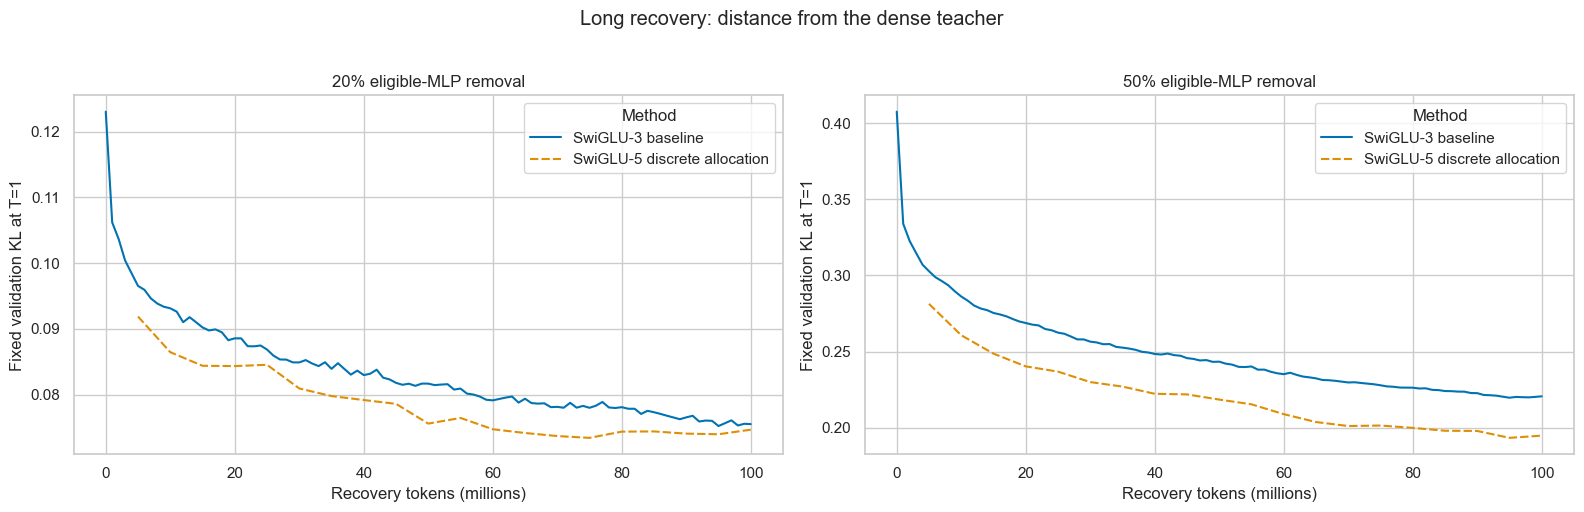

In [83]:
method_order = ['SwiGLU-3 baseline', 'SwiGLU-5 discrete allocation']
method_palette = dict(zip(method_order, sns.color_palette('colorblind', 2)))
figure, axes = plt.subplots(1, 2, figsize=(16, 5))
for axis, target in zip(axes, ('0.2', '0.5')):
    sns.lineplot(
        data=validation_df[validation_df['target'] == target],
        x='tokens_millions',
        y='validation_kl',
        hue='method',
        style='method',
        hue_order=method_order,
        style_order=method_order,
        palette=method_palette,
        dashes=True,
        estimator=None,
        ax=axis,
    )
    axis.set(
        title=f'{float(target):.0%} eligible-MLP removal',
        xlabel='Recovery tokens (millions)',
        ylabel='Fixed validation KL at T=1',
    )
    axis.legend(title='Method')
figure.suptitle('Long recovery: distance from the dense teacher', y=1.02)
figure.tight_layout()
plt.show()


c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

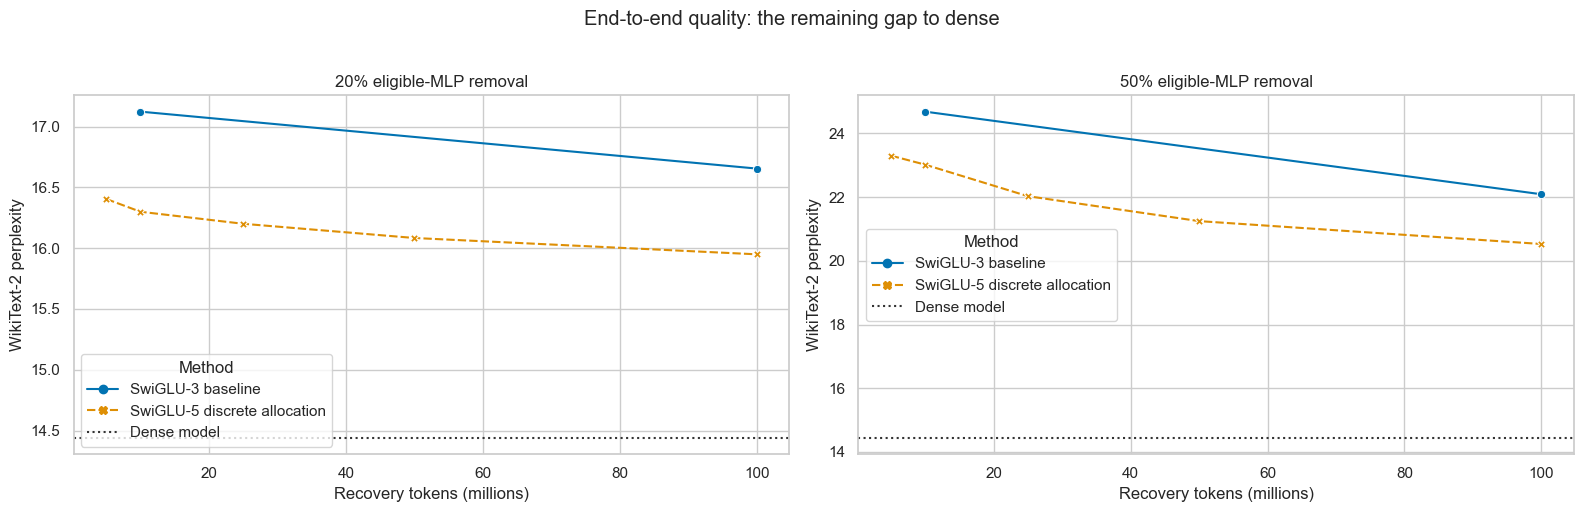

In [84]:
figure, axes = plt.subplots(1, 2, figsize=(16, 5))
for axis, target in zip(axes, ('0.2', '0.5')):
    sns.lineplot(
        data=perplexity_df[perplexity_df['target'] == target],
        x='tokens_millions',
        y='perplexity',
        hue='method',
        style='method',
        hue_order=method_order,
        style_order=method_order,
        palette=method_palette,
        markers=True,
        dashes=True,
        estimator=None,
        ax=axis,
    )
    axis.axhline(
        dense_ppl, color='0.2', linestyle=':', linewidth=1.5, label='Dense model'
    )
    axis.set(
        title=f'{float(target):.0%} eligible-MLP removal',
        xlabel='Recovery tokens (millions)',
        ylabel='WikiText-2 perplexity',
    )
    axis.legend(title='Method')
figure.suptitle('End-to-end quality: the remaining gap to dense', y=1.02)
figure.tight_layout()
plt.show()


In [85]:
display(
    paired_df.style.format({
        'SwiGLU-3 KL': '{:.4f}',
        'SwiGLU-5 KL': '{:.4f}',
        'KL improvement': '{:.4f}',
        'SwiGLU-3 PPL': '{:.3f}',
        'SwiGLU-5 PPL': '{:.3f}',
        'PPL improvement': '{:.3f}',
    })
)


,Target,Budget,SwiGLU-3 KL,SwiGLU-5 KL,KL improvement,SwiGLU-3 PPL,SwiGLU-5 PPL,PPL improvement
0,20% removal,10M,0.0931,0.0865,0.0067,17.123,16.299,0.823
1,20% removal,100M,0.0755,0.0747,0.0008,16.654,15.949,0.705
2,50% removal,10M,0.2862,0.2607,0.0254,24.686,23.022,1.665
3,50% removal,100M,0.2207,0.1949,0.0258,22.091,20.529,1.562


#### Efficiency — faster evidence, not just better metrics

In [86]:
resource_rows = []
efficiency_summary_rows = []
for target, artifact in confirmations.items():
    comparison = next(
        row for row in artifact['results']['paired_swiglu_3_comparison']
        if row['requested_tokens'] == 100_000_000
    )
    source = comparison['swiglu_3']
    improved = comparison['swiglu_5']
    target_label = f'{float(target):.0%} removal'
    for method, values in (('SwiGLU-3', source), ('SwiGLU-5', improved)):
        resource_rows.extend([
            {
                'target': target_label, 'method': method,
                'metric': 'Runtime (hours)', 'value': values['elapsed_seconds'] / 3600,
            },
            {
                'target': target_label, 'method': method,
                'metric': 'Peak RAM (GiB)', 'value': values['memory']['peak_ram_gib'],
            },
            {
                'target': target_label, 'method': method,
                'metric': 'Peak VRAM (GiB)', 'value': values['memory']['peak_vram_gib'],
            },
        ])
    efficiency_summary_rows.append({
        'Target': target_label,
        'Runtime speedup': source['elapsed_seconds'] / improved['elapsed_seconds'],
        'SwiGLU-3 throughput': source['tokens_per_second'],
        'SwiGLU-5 throughput': improved['tokens_per_second'],
        'RAM reduction': 1 - improved['memory']['peak_ram_gib'] / source['memory']['peak_ram_gib'],
        'VRAM change': improved['memory']['peak_vram_gib'] / source['memory']['peak_vram_gib'] - 1,
    })
resource_df = pd.DataFrame(resource_rows)
efficiency_summary_df = pd.DataFrame(efficiency_summary_rows)


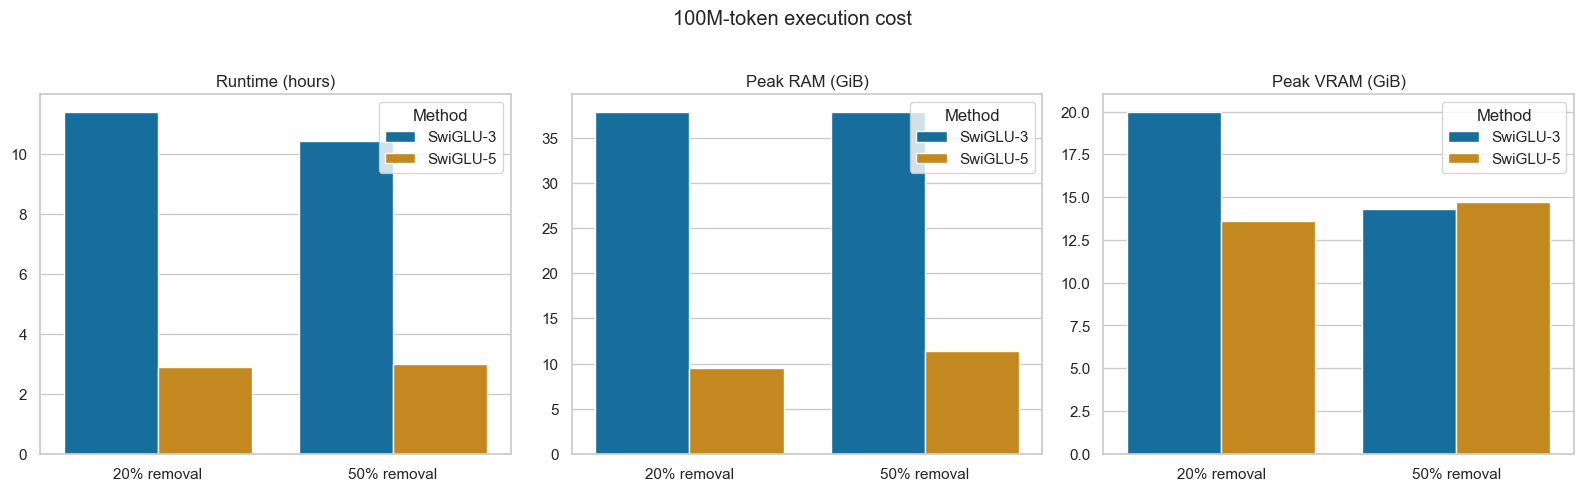

In [87]:
resource_palette = dict(zip(
    ['SwiGLU-3', 'SwiGLU-5'], sns.color_palette('colorblind', 2)
))
figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, metric in zip(axes, ['Runtime (hours)', 'Peak RAM (GiB)', 'Peak VRAM (GiB)']):
    sns.barplot(
        data=resource_df[resource_df['metric'] == metric],
        x='target',
        y='value',
        hue='method',
        palette=resource_palette,
        ax=axis,
    )
    axis.set(title=metric, xlabel='', ylabel='')
    axis.legend(title='Method')
figure.suptitle('100M-token execution cost', y=1.02)
figure.tight_layout()
plt.show()


In [88]:
display(
    efficiency_summary_df.style.format({
        'Runtime speedup': '{:.2f}×',
        'SwiGLU-3 throughput': '{:,.0f} tok/s',
        'SwiGLU-5 throughput': '{:,.0f} tok/s',
        'RAM reduction': '{:.1%}',
        'VRAM change': '{:+.1%}',
    })
)


,Target,Runtime speedup,SwiGLU-3 throughput,SwiGLU-5 throughput,RAM reduction,VRAM change
0,20% removal,3.93×,"2,433 tok/s","9,574 tok/s",75.0%,-31.9%
1,50% removal,3.49×,"2,662 tok/s","9,291 tok/s",69.9%,+2.9%


#### From recovery tuning to structural improvement

In [89]:
swiglu_4_rows = {
    row['trajectory_id']: row for row in swiglu_4['results']['final_comparison']
}
confirmation_50_10m = next(
    row for row in confirmations['0.5']['results']['paired_swiglu_3_comparison']
    if row['requested_tokens'] == 10_000_000
)['swiglu_5']
progression_df = pd.DataFrame([
    {
        'Step': 'SwiGLU-3 baseline',
        'What changed': 'Original recovery recipe',
        'KL': swiglu_4_rows['swiglu3_0.5_10m']['recovery_validation_kl_t1'],
        'Perplexity': swiglu_4_rows['swiglu3_0.5_10m']['wikitext_validation_perplexity'],
    },
    {
        'Step': 'SwiGLU-4 tuned recovery',
        'What changed': 'Constant 3e-5 recovery',
        'KL': swiglu_4_rows['C1']['recovery_validation_kl_t1'],
        'Perplexity': swiglu_4_rows['C1']['wikitext_validation_perplexity'],
    },
    {
        'Step': 'SwiGLU-4 assisted LoRA',
        'What changed': 'Transformer-assisted adaptation',
        'KL': swiglu_4_rows['L2']['recovery_validation_kl_t1'],
        'Perplexity': swiglu_4_rows['L2']['wikitext_validation_perplexity'],
    },
    {
        'Step': 'SwiGLU-5 discrete allocation',
        'What changed': 'Width budget moved between layers',
        'KL': confirmation_50_10m['recovery_validation_kl'],
        'Perplexity': confirmation_50_10m['wikitext_validation_perplexity'],
    },
])


c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\samue\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning

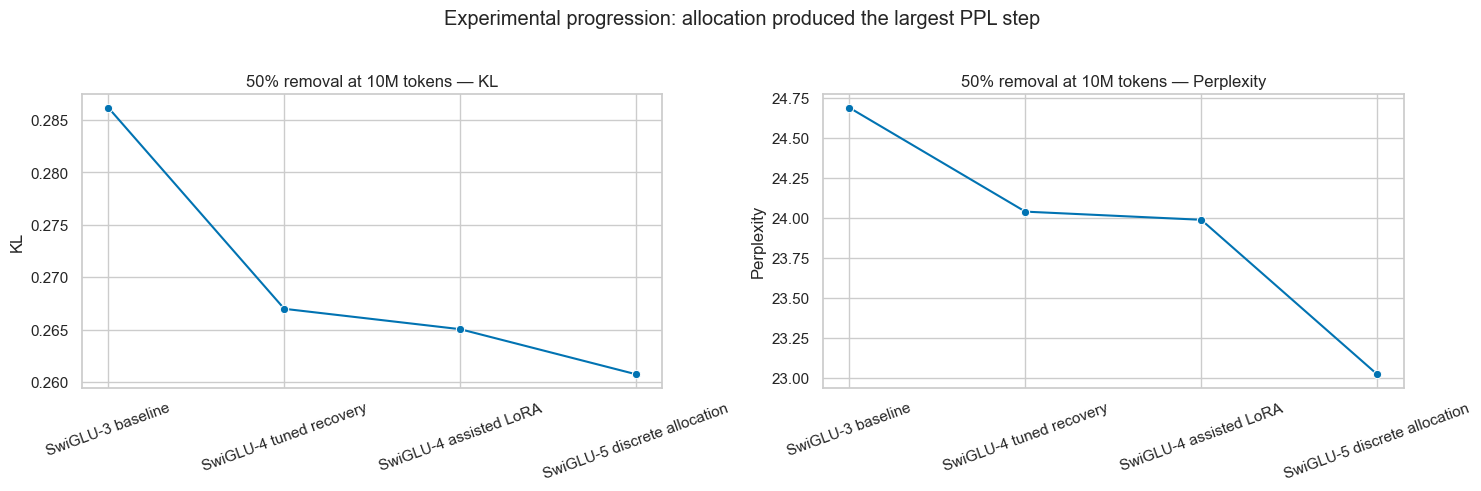

In [90]:
figure, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for axis, metric in zip(axes, ['KL', 'Perplexity']):
    sns.lineplot(
        data=progression_df, x='Step', y=metric, marker='o',
        color=sns.color_palette('colorblind')[0], ax=axis
    )
    axis.set(title=f'50% removal at 10M tokens — {metric}', xlabel='', ylabel=metric)
    axis.tick_params(axis='x', rotation=20)
figure.suptitle('Experimental progression: allocation produced the largest PPL step', y=1.02)
figure.tight_layout()
plt.show()


In [91]:
display(progression_df)


,Step,What changed,KL,Perplexity
0,SwiGLU-3 baseline,Original recovery recipe,0.286172,24.686103
1,SwiGLU-4 tuned recovery,Constant 3e-5 recovery,0.266991,24.037321
2,SwiGLU-4 assisted LoRA,Transformer-assisted adaptation,0.265047,23.986389
3,SwiGLU-5 discrete allocation,Width budget moved between layers,0.260746,23.021546


#### Decision